In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['text.usetex'] = True

In [2]:
df = pd.read_csv('Ratio.csv')
df.head()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp
0,45.845272,41.0,4.491525,2.655975,1.718447,208.279468,0.558946,0.843663
1,54.441261,41.0,4.491525,2.655975,1.718447,208.279468,0.789461,0.760744
2,65.902579,41.0,4.491525,2.655975,1.718447,208.279468,0.978898,0.647926
3,74.498567,41.0,4.491525,2.655975,1.718447,208.279468,1.248814,0.570788
4,85.959885,41.0,4.491525,2.655975,1.718447,208.279468,1.607064,0.483207


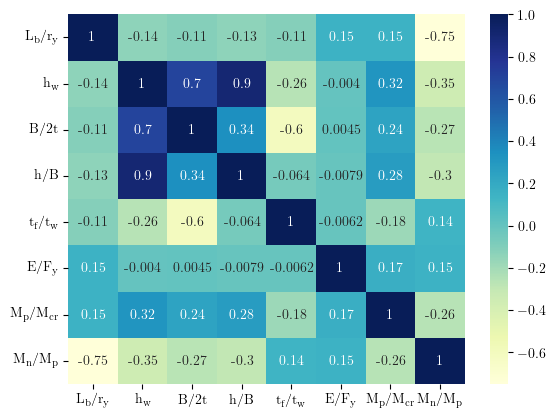

In [3]:
tempdf = df.rename(columns=
    {"Lb/ry": r"L\textsubscript{b}/r\textsubscript{y}",
     "h/tw" :r"h\textsubscript{w}",
     "tf/tw" : r"t\textsubscript{f}/t\textsubscript{w}",
     "E/Fy" : r"E/F\textsubscript{y}",
     "Mp/Mcr" : r"M\textsubscript{p}/M\textsubscript{cr}",
     "Mn/Mp" : r"M\textsubscript{n}/M\textsubscript{p}"
    }, errors="raise")
sns.heatmap(tempdf.corr(numeric_only=True), cmap="YlGnBu", annot=True)
plt.savefig(f'crosscorrelation.png', dpi=640, bbox_inches='tight')

In [4]:
df_stats = df.describe().transpose()
df_stats = df_stats[['mean', 'std']]
df_stats['variance'] = df_stats['std'] ** 2
df_stats

,mean,std,variance
Lb/ry,97.366596,37.083167,1375.161280
h/tw,34.963695,14.070018,197.965420
B/2t,5.634730,1.363515,1.859172
h/B,1.853852,0.583968,0.341018
tf/tw,1.653545,0.116217,0.013506
E/Fy,248.937214,40.796326,1664.340176
Mp/Mcr,1.624280,0.948242,0.899163
Mn/Mp,0.564298,0.189916,0.036068


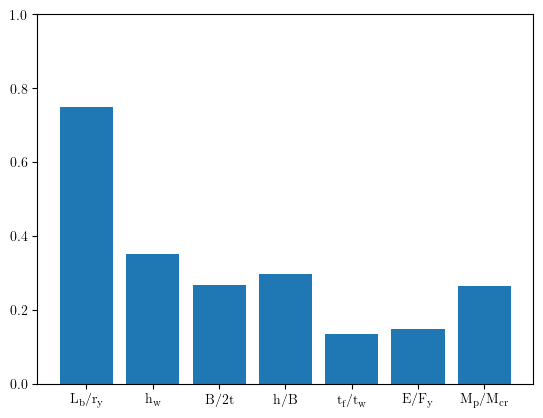

In [5]:
C = tempdf.corr(numeric_only=True)[r'M\textsubscript{n}/M\textsubscript{p}'][:-1]
plt.bar(C.index, np.abs(C.values))
plt.ylim([0, 1])

plt.savefig(f'correlation-with-Mn-Mp.png', dpi=640, bbox_inches='tight')

In [6]:
X_full = df[['Lb/ry', 'h/tw', 'B/2t', 'h/B', 'tf/tw', 'E/Fy', 'Mp/Mcr']]
y_full = df['Mn/Mp']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=123)

In [8]:
def evaluate_pipeline(pipeline, threshold=0.2):
    pipeline_train_prd = pipeline.predict(X_train)
    pipeline_train_outliers = np.abs(pipeline_train_prd - y_train) > threshold
    mod_pipeline_train_prd = pipeline_train_prd[~ pipeline_train_outliers]
    mod_y_train = y_train[~ pipeline_train_outliers]
    pipeline_train_mse = mean_squared_error(mod_pipeline_train_prd, mod_y_train)
    pipeline_train_mae = mean_absolute_error(mod_pipeline_train_prd, mod_y_train)
    pipeline_train_r2_score = r2_score(mod_pipeline_train_prd, mod_y_train)
    
    pipeline_test_prd = pipeline.predict(X_test)
    pipeline_test_outliers = np.abs(pipeline_test_prd - y_test) > threshold
    mod_pipeline_test_prd = pipeline_test_prd[~ pipeline_test_outliers]
    mod_y_test = y_test[~ pipeline_test_outliers]
    pipeline_test_mse = mean_squared_error(mod_pipeline_test_prd, mod_y_test)
    pipeline_test_mae = mean_absolute_error(mod_pipeline_test_prd, mod_y_test)
    pipeline_test_r2_score = r2_score(mod_pipeline_test_prd, mod_y_test)
    
    pipeline_full_prd = pipeline.predict(X_full)
    pipeline_full_outliers = np.abs(pipeline_full_prd - y_full) > threshold
    mod_pipeline_full_prd = pipeline_full_prd[~ pipeline_full_outliers]
    mod_y_full = y_full[~ pipeline_full_outliers]
    pipeline_full_mse = mean_squared_error(mod_pipeline_full_prd, mod_y_full)
    pipeline_full_mae = mean_absolute_error(mod_pipeline_full_prd, mod_y_full)
    pipeline_full_r2_score = r2_score(mod_pipeline_full_prd, mod_y_full)
    
    metrics = {
        'y_train': mod_y_train,
        'y_test' : mod_y_test,
        'train_mse': pipeline_train_mse,
        'train_mae': pipeline_train_mae,
        'train_r2': pipeline_train_r2_score,
        'test_mse': pipeline_test_mse,
        'test_mae': pipeline_test_mae,
        'test_r2': pipeline_test_r2_score,
        'full_mse': pipeline_full_mse,
        'full_mae': pipeline_full_mae,
        'full_r2': pipeline_full_r2_score,
        'train_predictions': mod_pipeline_train_prd,
        'test_predictions': mod_pipeline_test_prd
    }

    return metrics

def plot_accuracy(pipeline_metrics, title):
    print(title)
    print(pipeline_metrics)
    y_train = pipeline_metrics['y_train']
    y_test = pipeline_metrics['y_test']
    
    pipeline_train_prd = pipeline_metrics['train_predictions']
    pipeline_test_prd = pipeline_metrics['test_predictions']
    pipeline_train_r2_score = pipeline_metrics['train_r2']
    pipeline_test_r2_score = pipeline_metrics['test_r2']
    pipeline_full_r2_score = pipeline_metrics['full_r2']
    
    
    fig_train, axes = plt.subplots(figsize=(4, 4))
    axes.plot([0, 1], [0, 1])
    axes.text(0.1, 0.7, f'$R^2={pipeline_train_r2_score:.5f}$')
    axes.plot(y_train, pipeline_train_prd, 'bo', alpha=0.5, markeredgewidth=0.1, label='Train data');
    axes.set_xlabel('Actual Value')
    axes.set_ylabel('Predicted Value')
    axes.legend()
    fig_train.savefig(f'{title}/{title}-train.png', dpi=640, bbox_inches='tight')

    fig_test, axes = plt.subplots(figsize=(4, 4))
    axes.plot([0, 1], [0, 1])
    axes.text(0.1, 0.7, f'$R^2={pipeline_test_r2_score:.5f}$')
    axes.plot(y_test, pipeline_test_prd, 'ro', alpha=0.5, markeredgewidth=0.1, label='Test data');
    axes.set_xlabel('Actual Value')
    axes.set_ylabel('Predicted Value')
    axes.legend()
    fig_test.savefig(f'{title}/{title}-test.png', dpi=640, bbox_inches='tight')

    fig_full, axes = plt.subplots(figsize=(4, 4))
    axes.plot([0, 1], [0, 1])
    axes.text(0.1, 0.7, f'$R^2={pipeline_full_r2_score:.5f}$')
    axes.plot(y_train, pipeline_train_prd, 'bo', alpha=0.5, markeredgewidth=0.1, label='Train data');
    axes.plot(y_test, pipeline_test_prd, 'ro', alpha=0.5, markeredgewidth=0.1, label='Test data');
    axes.set_xlabel('Actual Value')
    axes.set_ylabel('Predicted Value')
    axes.legend()
    fig_full.savefig(f'{title}/{title}-full.png', dpi=640, bbox_inches='tight')

def plot_cross_validation(cv_result, titlename):
    mean_mse = cv_result['mean_test_score']
    criterions = cv_result['params'][0].keys()
    
    params_df = pd.DataFrame(cv_result['params'].tolist())
    heatmap_data = params_df.copy()
    heatmap_data['mean_r2'] = mean_mse
    if all(mean_mse < 0):
        heatmap_data['mean_r2'] = -mean_mse

    for col in params_df.columns:
        df = heatmap_data.groupby(col)['mean_r2'].min()
        metrics = df.keys().tolist()
        values = df.values.tolist()
        
        angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()

        values = np.concatenate((values, [values[0]]))  # Close the loop
        angles += angles[:1]
        
        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
        # print(np.max(values) * 1.1)
        # ax.set_rlim(np.max(values) * 1.1)
        ax.margins(0.1)
        ax.scatter(angles, values)
        ax.plot(angles, values, '--')
        ax.fill(angles, values, alpha=0.25)
        
        # Set axis labels
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(metrics)

        plt.savefig(f'{titlename}/{titlename}-hyperparam-{col}.png', dpi=640, bbox_inches='tight')

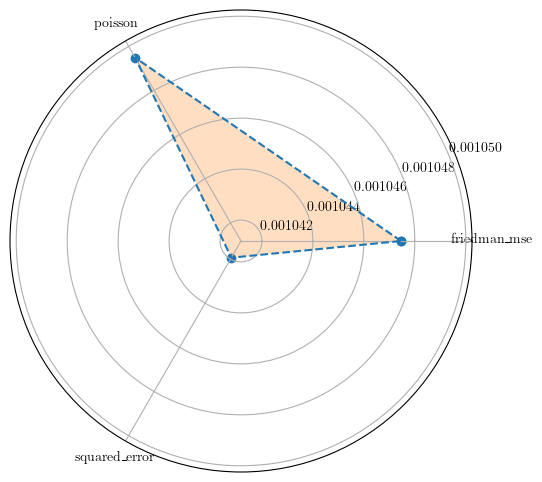

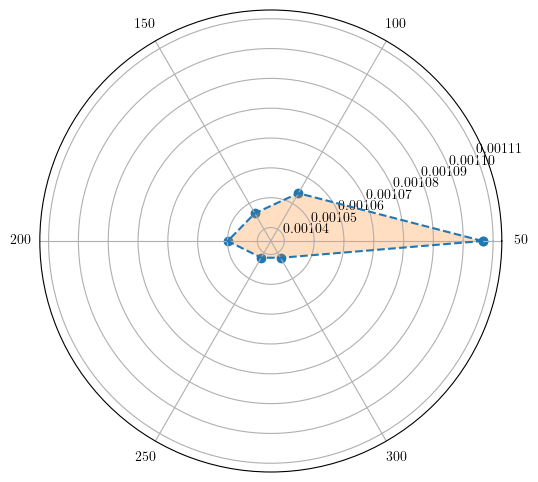

In [9]:
rf_params = {
    'criterion' : ['squared_error', 'friedman_mse', 'poisson'],
    'n_estimators' : [50, 100, 150, 200, 250, 300],
}

rf_cv = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, scoring='neg_mean_squared_error')
rf_cv.fit(X_train, y_train)
rf_best = rf_cv.best_estimator_
rf_metrics = evaluate_pipeline(rf_best)

rf_cv_result = pd.DataFrame(rf_cv.cv_results_)
plot_cross_validation(rf_cv_result, 'random-forest')

random-forest
{'y_train': 21     0.587692
430    0.276756
79     0.630164
408    0.692862
313    0.832889
         ...   
230    0.651196
98     0.689246
322    0.846593
382    0.591085
365    0.558731
Name: Mn/Mp, Length: 352, dtype: float64, 'y_test': 13     0.301036
125    0.643799
287    0.409213
204    0.552481
172    0.615535
         ...   
199    0.352128
31     0.386317
240    0.753010
59     0.382423
328    0.426775
Name: Mn/Mp, Length: 89, dtype: float64, 'train_mse': 0.00012393592713143433, 'train_mae': 0.007611368377886381, 'train_r2': 0.9963729579588495, 'test_mse': 0.0006322251720869567, 'test_mae': 0.01873371248382027, 'test_r2': 0.9813861508234758, 'full_mse': 0.00022651584278005453, 'full_mae': 0.009856013787020433, 'full_r2': 0.9933752199217437, 'train_predictions': array([0.58021218, 0.27146172, 0.6309638 , 0.69739713, 0.79005876,
       0.54929841, 0.41017075, 0.64484248, 0.4019365 , 0.33092088,
       0.74815266, 0.34663822, 0.90723068, 0.77100886, 0.59936387,
   

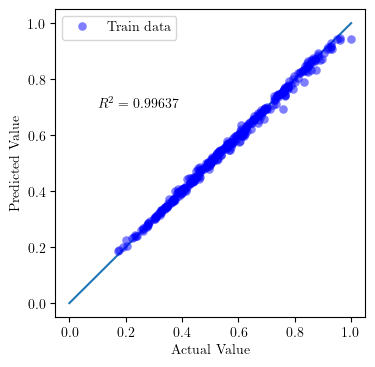

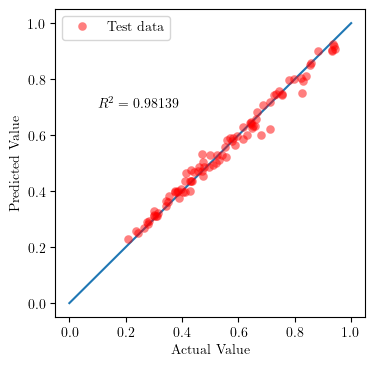

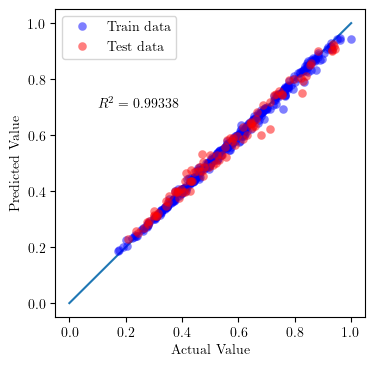

In [10]:
rf_metrics = evaluate_pipeline(rf_best)
plot_accuracy(rf_metrics, 'random-forest')

In [9]:
gb_params = {
    'n_estimators' : [500, 1000, 2000, 3000, 4000, 5000],
    'learning_rate' : [0.01, 0.02, 0.05, 0.1, 0.2],
    'max_depth' : [1, 2, 3, 4],
}

gb_cv = GridSearchCV(GradientBoostingRegressor(random_state=42, subsample=0.7), gb_params, scoring='neg_mean_squared_error')
gb_cv.fit(X_train, y_train)
gb_best = gb_cv.best_estimator_

print(gb_cv.best_params_)

{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 4000}


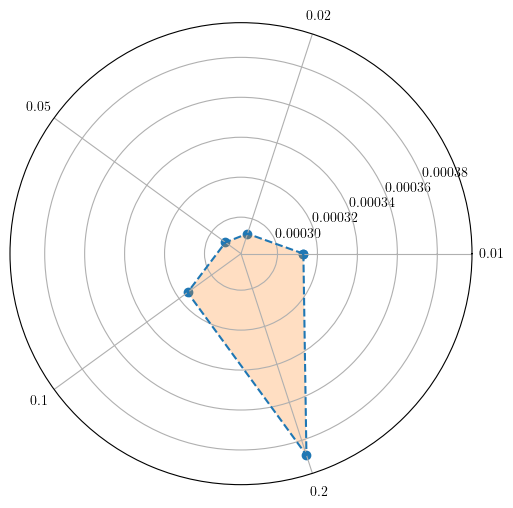

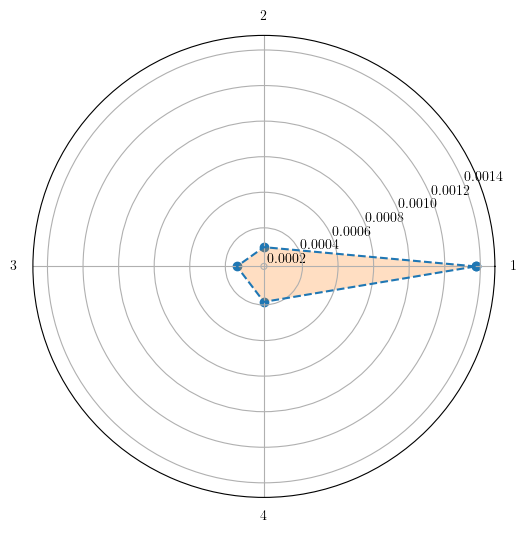

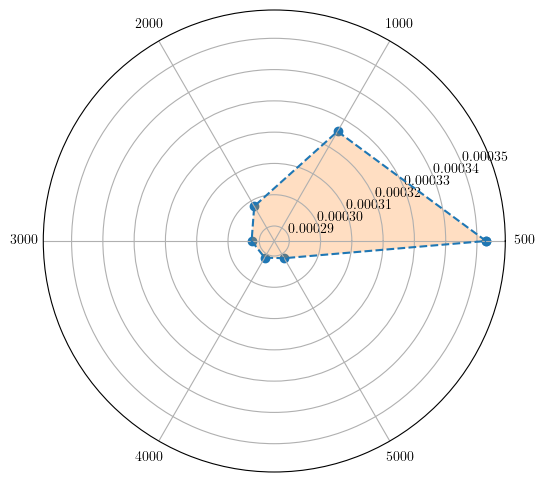

In [10]:
gb_cv_result = pd.DataFrame(gb_cv.cv_results_)
plot_cross_validation(gb_cv_result, 'gradient-boosting')

gradient-boosting
{'y_train': 21     0.587692
430    0.276756
79     0.630164
408    0.692862
313    0.832889
         ...   
230    0.651196
98     0.689246
322    0.846593
382    0.591085
365    0.558731
Name: Mn/Mp, Length: 352, dtype: float64, 'y_test': 13     0.301036
125    0.643799
287    0.409213
204    0.552481
172    0.615535
         ...   
199    0.352128
31     0.386317
240    0.753010
59     0.382423
328    0.426775
Name: Mn/Mp, Length: 89, dtype: float64, 'train_mse': 1.4806082289527988e-06, 'train_mae': 0.0009848116362569318, 'train_r2': 0.9999582259150721, 'test_mse': 9.538576413051198e-05, 'test_mae': 0.007476194440422824, 'test_r2': 0.9974353046040467, 'full_mse': 2.0431988898428464e-05, 'full_mae': 0.0022948639482087787, 'full_r2': 0.9994302410628587, 'train_predictions': array([0.58643291, 0.27771133, 0.63237856, 0.69276063, 0.83279044,
       0.55657196, 0.40686337, 0.63852601, 0.40169411, 0.32471465,
       0.74920536, 0.34872489, 0.91499491, 0.77616335, 0.599072

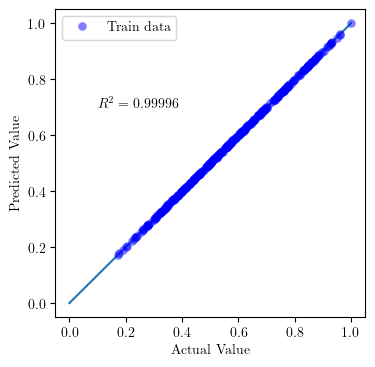

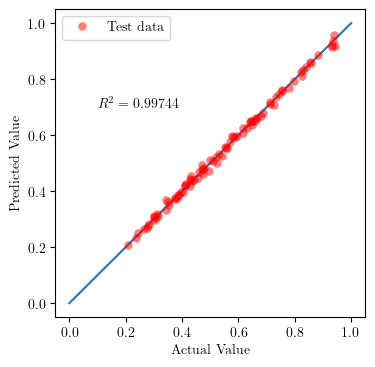

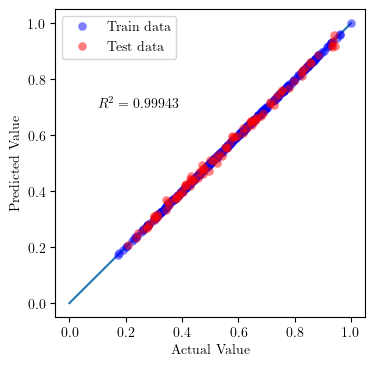

In [11]:
gb_metrics = evaluate_pipeline(gb_best, 1000000000)
plot_accuracy(gb_metrics, 'gradient-boosting')

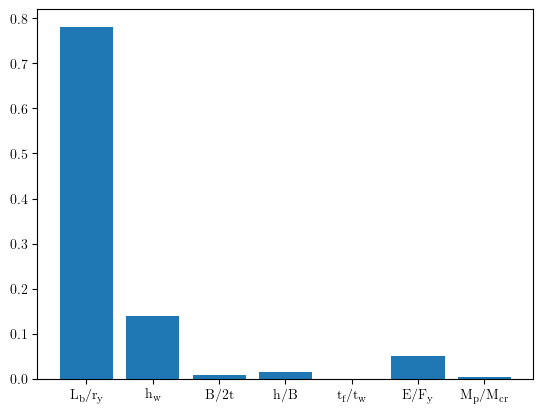

In [12]:
feature_importance = gb_best.feature_importances_
plt.bar(tempdf.columns[:7], feature_importance)
plt.savefig('gradient-boosting/feature-imp.png', dpi=640, bbox_inches='tight')

In [15]:
from sklearn.svm import LinearSVR, SVR
from scipy.stats import loguniform, uniform
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

kernels = ['linear', 'rbf', 'poly']
svr_params = {
    'svr__C': loguniform(1e-1, 1e2),
    'svr__epsilon': uniform(0.01, 0.1)
}

svr_metrics = dict()

for kernel in ['linear', 'rbf', 'poly']:
    if kernel == 'linear':
        base_model = SVR(kernel=kernel)
        base_params = svr_params
    else:
        base_model = SVR(kernel=kernel)
        base_params = {**svr_params, 'svr__gamma': loguniform(1e-3, 1e3)}

    svr_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', base_model)
    ])

    svr_cv = RandomizedSearchCV(svr_pipeline, base_params, n_iter=10, random_state=100, n_jobs=-1, scoring='neg_mean_squared_error')
    svr_cv.fit(X_train, y_train)
    
    svr_best = svr_cv.best_estimator_
    svr_cv_result = pd.DataFrame(svr_cv.cv_results_)
    print(svr_cv.best_params_)

    svr_metrics[kernel] = evaluate_pipeline(svr_best)

{'svr__C': 0.2571104740261944, 'svr__epsilon': 0.067509332942725}
{'svr__C': 34.2238132147075, 'svr__epsilon': 0.010471885619097256, 'svr__gamma': 0.005363085549653507}
{'svr__C': 4.2679058013626765, 'svr__epsilon': 0.037836938509379615, 'svr__gamma': 0.3524565164435525}


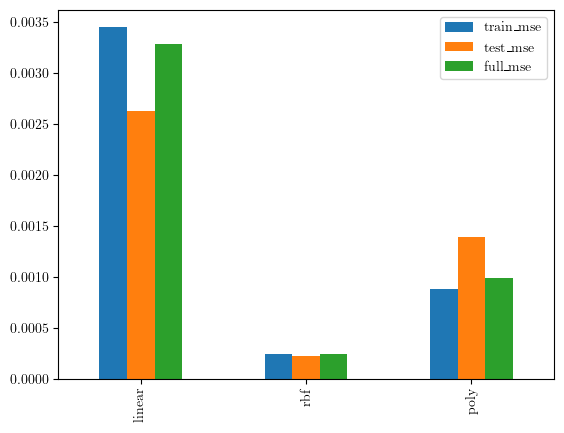

In [16]:
pd.DataFrame(svr_metrics).filter(regex='_mse', axis=0).transpose().plot.bar()
plt.savefig('svr/svr-kernel-mse.png', dpi=640, bbox_inches='tight')

SVR-linear
{'y_train': 21     0.587692
430    0.276756
79     0.630164
408    0.692862
313    0.832889
         ...   
230    0.651196
98     0.689246
322    0.846593
382    0.591085
365    0.558731
Name: Mn/Mp, Length: 348, dtype: float64, 'y_test': 13     0.301036
125    0.643799
287    0.409213
204    0.552481
172    0.615535
         ...   
199    0.352128
31     0.386317
240    0.753010
59     0.382423
328    0.426775
Name: Mn/Mp, Length: 88, dtype: float64, 'train_mse': 0.0034459407291404973, 'train_mae': 0.049002015959143025, 'train_r2': 0.8840416540275772, 'test_mse': 0.002632206666460418, 'test_mae': 0.04413252137809125, 'test_r2': 0.9223669235263329, 'full_mse': 0.003281700826581215, 'full_mae': 0.048019182190490374, 'full_r2': 0.892823595753637, 'train_predictions': array([0.63341084, 0.26533492, 0.59531256, 0.63362958, 0.89768763,
       0.59573723, 0.46387018, 0.60367028, 0.46743336, 0.35766054,
       0.71257173, 0.39021914, 0.90049208, 0.76081231, 0.62100096,
       0.86

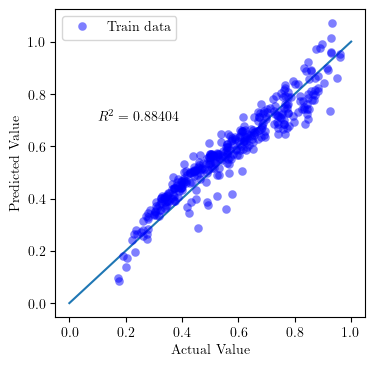

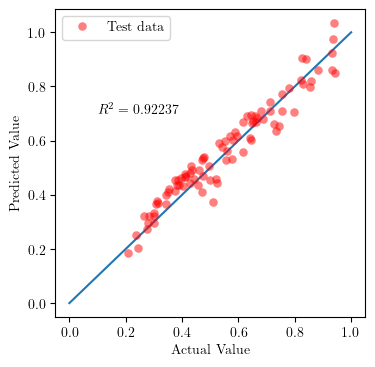

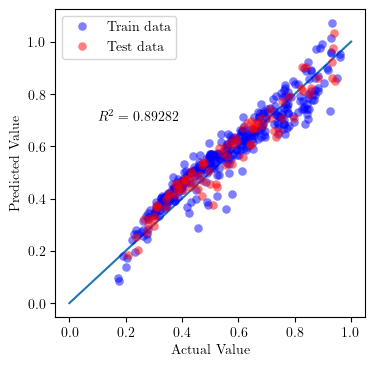

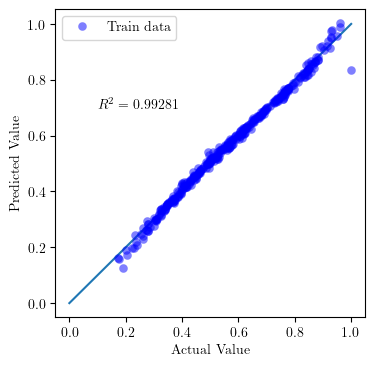

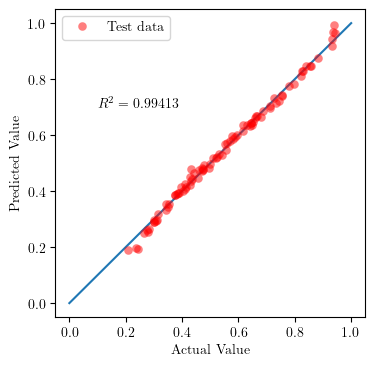

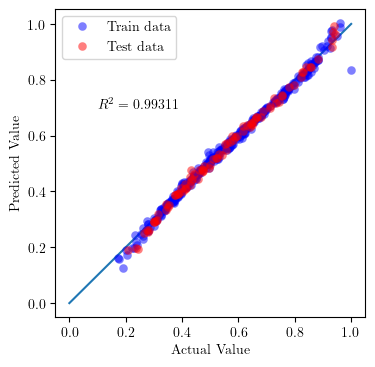

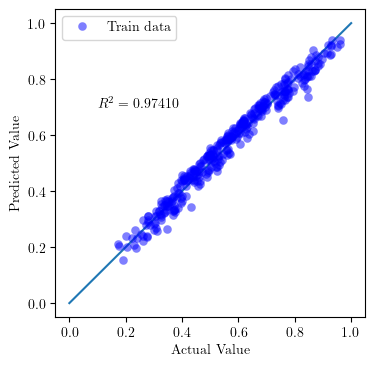

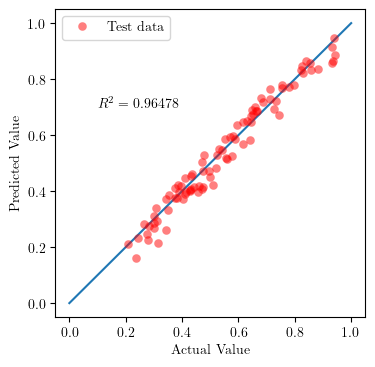

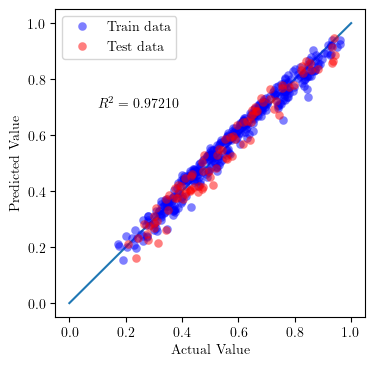

In [17]:
for kernel in kernels:
    plot_accuracy(svr_metrics[kernel], f'SVR-{kernel}')

In [18]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

nn_params = {
    'mlp__hidden_layer_sizes' : [(20, 20, 20, 20, 20, 20, 20)],
    'mlp__activation' : ['relu'],
    'mlp__solver': ['lbfgs']
}

nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=100, early_stopping=True, max_iter=1000))
])

nn_cv = GridSearchCV(nn_pipeline, nn_params, scoring='neg_mean_squared_error')
nn_cv.fit(X_train, y_train)

nn_best = nn_cv.best_estimator_
nn_cv_result = pd.DataFrame(nn_cv.cv_results_)

# plt.subplot(2, 1, 1)
# plt.semilogy(nn_best['mlp'].loss_curve_)
# plt.subplot(2, 1, 2)
# plt.plot(nn_best['mlp'].validation_scores_)
# plt.savefig('MLP/mlp.png', dpi=640, bbox_inches='tight')

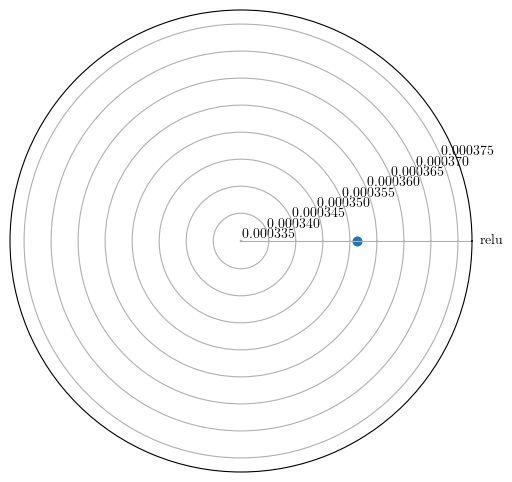

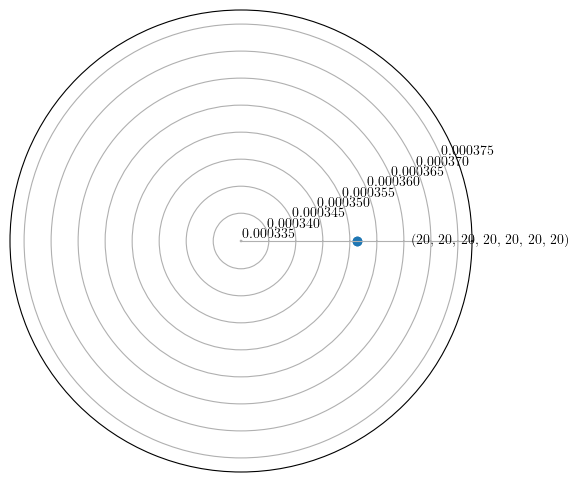

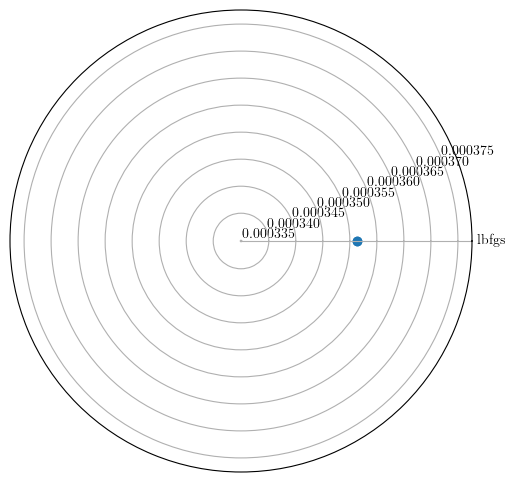

In [19]:
plot_cross_validation(nn_cv_result, 'mlp-hyperparams')

MLP
{'y_train': 21     0.587692
430    0.276756
79     0.630164
408    0.692862
313    0.832889
         ...   
230    0.651196
98     0.689246
322    0.846593
382    0.591085
365    0.558731
Name: Mn/Mp, Length: 352, dtype: float64, 'y_test': 13     0.301036
125    0.643799
287    0.409213
204    0.552481
172    0.615535
         ...   
199    0.352128
31     0.386317
240    0.753010
59     0.382423
328    0.426775
Name: Mn/Mp, Length: 89, dtype: float64, 'train_mse': 0.00013884354370890948, 'train_mae': 0.008549406039363196, 'train_r2': 0.9960747549011186, 'test_mse': 0.00021353362167234597, 'test_mae': 0.01100510586206444, 'test_r2': 0.9942217678397748, 'full_mse': 0.00015391705150651907, 'full_mae': 0.009045000788162312, 'full_r2': 0.9956939930920636, 'train_predictions': array([0.59981688, 0.27572197, 0.63516429, 0.70208211, 0.84833136,
       0.55661962, 0.40441467, 0.64022343, 0.40812393, 0.32246213,
       0.75566047, 0.34990022, 0.90585643, 0.76443102, 0.59449393,
       0.882

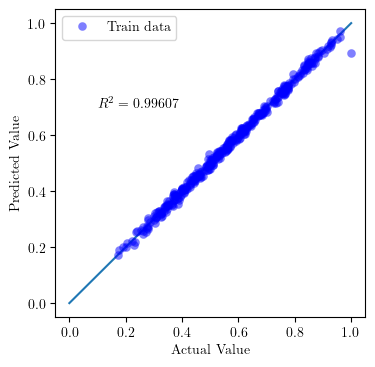

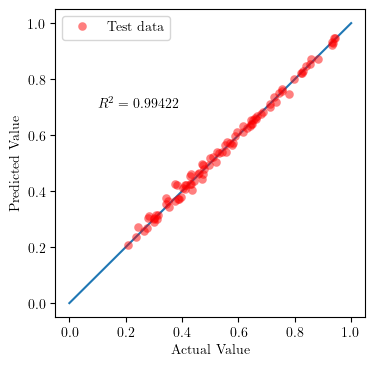

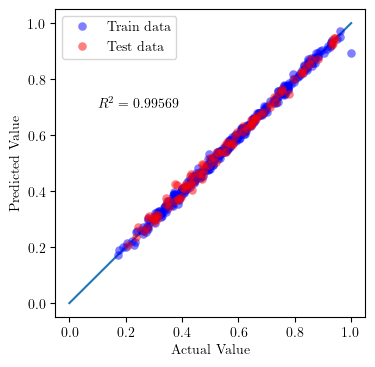

In [20]:
nn_metrics = evaluate_pipeline(nn_best, 0.3)
plot_accuracy(nn_metrics, 'MLP')

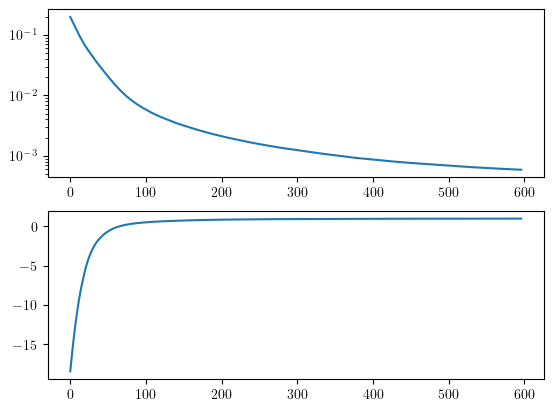

In [21]:
small_nn_params = {
    'mlp__hidden_layer_sizes' : [(x,) for x in range(1, 15)],
    'mlp__activation' : ['relu', 'tanh', 'logistic']
}

small_nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=100, early_stopping=True, max_iter=2000))
])

small_nn_cv = GridSearchCV(small_nn_pipeline, small_nn_params, scoring='neg_mean_squared_error')
small_nn_cv.fit(X_train, y_train)

small_nn_best = small_nn_cv.best_estimator_
small_nn_cv_result = pd.DataFrame(small_nn_cv.cv_results_)

plt.subplot(2, 1, 1)
plt.semilogy(small_nn_best['mlp'].loss_curve_)
plt.subplot(2, 1, 2)
plt.plot(small_nn_best['mlp'].validation_scores_)
plt.savefig('small-nn/small-nn.png', dpi=640, bbox_inches='tight')

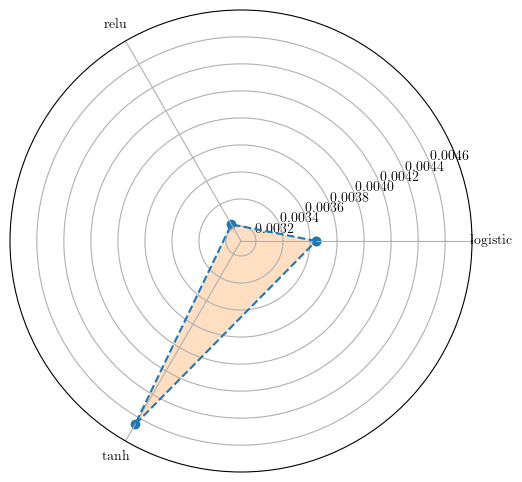

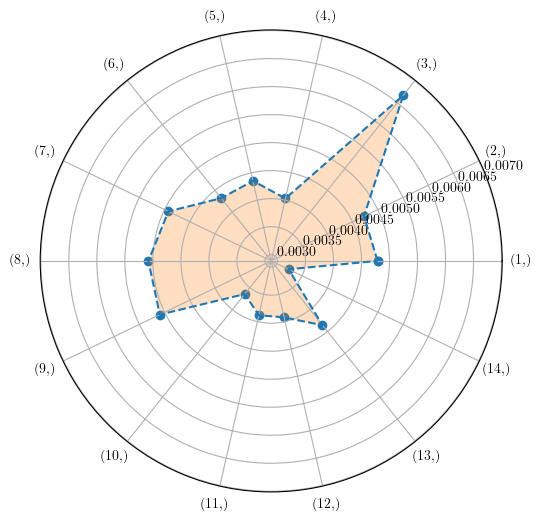

In [22]:
plot_cross_validation(small_nn_cv_result, 'small-nn-hyperparameters')

small-nn
{'y_train': 21     0.587692
430    0.276756
79     0.630164
408    0.692862
313    0.832889
         ...   
230    0.651196
98     0.689246
322    0.846593
382    0.591085
365    0.558731
Name: Mn/Mp, Length: 352, dtype: float64, 'y_test': 13     0.301036
125    0.643799
287    0.409213
204    0.552481
172    0.615535
         ...   
199    0.352128
31     0.386317
240    0.753010
59     0.382423
328    0.426775
Name: Mn/Mp, Length: 89, dtype: float64, 'train_mse': 0.001190487467525755, 'train_mae': 0.026728394239711115, 'train_r2': 0.9671852407204244, 'test_mse': 0.0017502531880452354, 'test_mae': 0.0322464256516792, 'test_r2': 0.952238071746911, 'full_mse': 0.0013034560596487338, 'full_mae': 0.027842010556412156, 'full_r2': 0.9641937744524773, 'train_predictions': array([0.60685405, 0.31666855, 0.63688414, 0.74056904, 0.82552468,
       0.59206624, 0.39896135, 0.67394756, 0.43394026, 0.37099892,
       0.74439928, 0.34890196, 0.93224722, 0.71359872, 0.63282853,
       0.8424

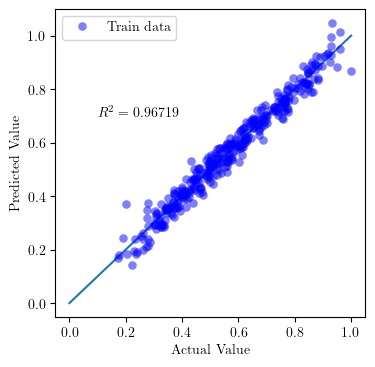

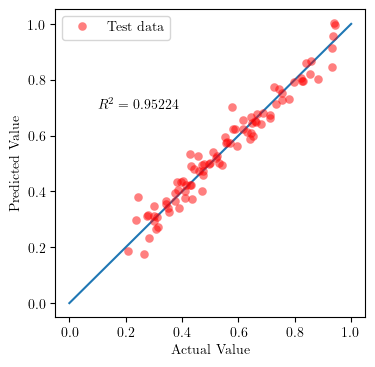

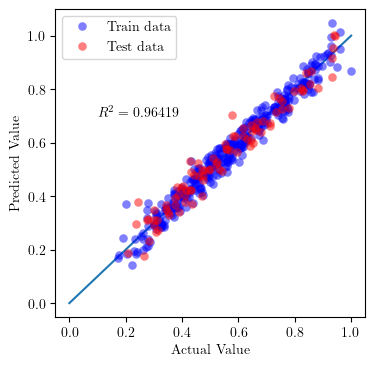

In [23]:
small_nn_metrics = evaluate_pipeline(small_nn_best, 100.0)
plot_accuracy(small_nn_metrics, 'small-nn')

In [24]:
og_data = pd.read_csv('original.csv')
og_data.head()

,Fy (ksi),Lb,bf,tf,tw,h0,ry,Mn(Modified),Mn(AISC code),Mn(FE model),Mp,b,Mcr
0,139.236,160,15.9,1.77,1.03,42.23,3.49,190298.5274,225562.320000,216638.377325,225562.32,15.9,399132.605082
1,139.236,190,15.9,1.77,1.03,42.23,3.49,171595.1703,219030.340139,197650.133747,225562.32,15.9,290051.468297
2,139.236,230,15.9,1.77,1.03,42.23,3.49,146147.7541,187966.043520,170240.744021,225562.32,15.9,205359.253150
3,139.236,260,15.9,1.77,1.03,42.23,3.49,128748.2021,155913.110942,139104.281134,225562.32,15.9,165618.043830
4,139.236,300,15.9,1.77,1.03,42.23,3.49,108993.2842,122477.537470,95629.312666,225562.32,15.9,129821.641396


In [25]:
og_data_ratio = pd.DataFrame()
og_data_ratio['Lb/ry'] = og_data['Lb'] / og_data['ry']
og_data_ratio['h/tw'] = og_data['h0'] / og_data['tw']
og_data_ratio['B/2t'] = og_data['b'] / 2 * og_data['tf']
og_data_ratio['h/B'] = og_data['h0'] / og_data['b']
og_data_ratio['tf/tw'] = og_data['tf'] / og_data['tw']
og_data_ratio['E/Fy'] = 29e3 / og_data['Fy (ksi)']
og_data_ratio['Mp/Mcr'] = og_data['Mp'] / og_data['Mcr']
og_data_ratio['Mn/Mp (AISC)'] = og_data['Mn(AISC code)'] / og_data['Mp']
og_data_ratio['Mn/Mp (MOD)'] = og_data['Mn(Modified)'] / og_data['Mp']

In [26]:
og_data_ratio.head()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp (AISC),Mn/Mp (MOD)
0,45.845272,41.0,14.0715,2.655975,1.718447,208.279468,0.565131,1.000000,0.843663
1,54.441261,41.0,14.0715,2.655975,1.718447,208.279468,0.777663,0.971041,0.760744
2,65.902579,41.0,14.0715,2.655975,1.718447,208.279468,1.098379,0.833322,0.647926
3,74.498567,41.0,14.0715,2.655975,1.718447,208.279468,1.361943,0.691220,0.570788
4,85.959885,41.0,14.0715,2.655975,1.718447,208.279468,1.737479,0.542988,0.483207


In [27]:
df.head()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp
0,45.845272,41.0,4.491525,2.655975,1.718447,208.279468,0.558946,0.843663
1,54.441261,41.0,4.491525,2.655975,1.718447,208.279468,0.789461,0.760744
2,65.902579,41.0,4.491525,2.655975,1.718447,208.279468,0.978898,0.647926
3,74.498567,41.0,4.491525,2.655975,1.718447,208.279468,1.248814,0.570788
4,85.959885,41.0,4.491525,2.655975,1.718447,208.279468,1.607064,0.483207


In [28]:
mse_code = mean_squared_error(og_data_ratio['Mn/Mp (AISC)'], og_data_ratio['Mn/Mp (MOD)'])
r2_code = r2_score(og_data_ratio['Mn/Mp (AISC)'], og_data_ratio['Mn/Mp (MOD)'])
print(mse_code)
print(r2_code)

0.027484151024631094
0.6181763301765262


In [29]:
mae_code = mean_absolute_error(og_data_ratio['Mn/Mp (AISC)'], og_data_ratio['Mn/Mp (MOD)'])
print(mae_code)

0.12830643132026942
